In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("data/training_data.parquet")

It seems like promotions are pop ups generated on the Fingerhut website after the user performs some other actions, such as browsing for products or completing their web application. It would be good to look into what events "trigger" these promotions (if any). In other words, what are the action(s) leading up to the event 'promotion_created', either based on a fixed number of previous events or a window of time before the event.

It would also be good to look at when these promotions are created with respect to certain milestones.

Also would be good to look at what the users next actions are following the generation of this promotion (either based on time or a fixed number of events).

In [30]:
np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None')

array(['catalog_(mail)', 'browse_products', 'campaignemail_clicked',
       'promotion_created', 'promotion_created', 'browse_products',
       'catalog_(mail)', 'None'], dtype=object)

In [32]:
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[df['outcome'] == 'successful'].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_successful = pd.DataFrame({
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [ ]:
successful_events_grouped = events_df_successful.groupby(['previous_event', 'next_event'])
display(successful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=12))
display(successful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

,,count,mean,median,var
previous_event,next_event,,,,
promotion_created,catalog_(mail),59549,10.233391,7.279942,162.826253
browse_products,browse_products,50333,2.192446,0.022581,126.827081
promotion_created,promotion_created,44149,14.391363,13.401481,421.650525
browse_products,promotion_created,31934,8.153199,2.481470,231.946174
catalog_(mail),promotion_created,30619,20.217432,21.299618,445.343392
promotion_created,None,20775,23.635409,18.381262,635.113956
browse_products,catalog_(mail),20484,12.549649,10.611134,168.899695
catalog_(mail),catalog_(mail),18946,18.192342,21.872685,383.591828
promotion_created,browse_products,18755,8.414070,0.591725,617.136432


,,count,mean,median,var
previous_event,next_event,,,,
promotion_created,catalog_(mail),59549,5.559544,3.108275,47.006068
browse_products,browse_products,50333,5.407163,0.956273,212.400953
promotion_created,promotion_created,44149,15.734973,3.587847,476.408119
browse_products,promotion_created,31934,10.133842,4.356308,168.505210
catalog_(mail),promotion_created,30619,16.737248,13.447141,301.966892
browse_products,catalog_(mail),20484,5.815355,3.977569,48.675880
catalog_(mail),catalog_(mail),18946,15.069507,6.122766,203.301021
promotion_created,browse_products,18755,13.548540,3.656574,689.285534
browse_products,view_cart,14919,5.306672,1.478079,115.556440


In [40]:
previous_events = []
previous_time_diffs = []
next_events = []
next_time_diffs = []

for i, row in enumerate(df[df['outcome'] == 'unsuccessful'].itertuples(index=False)):
    promotion_indices = np.where(row.event_names == 'promotion_created')[0]

    if len(promotion_indices) > 0:
        previous_indices = promotion_indices - 1
        previous_events.extend(row.event_names[previous_indices])
        previous_time_diffs.extend((row.timestamps[promotion_indices] - row.timestamps[previous_indices]) / np.timedelta64(1, 'D'))

        next_indices = promotion_indices + 1
        if next_indices[-1] < len(row.event_names):
            next_events.extend(row.event_names[next_indices])
        else:
            next_events.extend(np.append(row.event_names[next_indices[:len(next_indices) - 1]], 'None'))

        if next_indices[-1] < len(row.event_names):
            next_time_diffs.extend((row.timestamps[next_indices] - row.timestamps[promotion_indices]) / np.timedelta64(1, 'D'))
        else:
            next_time_diffs.extend(np.append((row.timestamps[next_indices[:len(next_indices) - 1]] - row.timestamps[promotion_indices[:len(promotion_indices) - 1]]) / np.timedelta64(1, 'D'), np.nan))


events_df_unsuccessful = pd.DataFrame({
    'previous_event': previous_events,
    'time_delta_previous': previous_time_diffs,
    'next_event': next_events,
    'time_delta_next': next_time_diffs
})

In [41]:
unsuccessful_events_grouped = events_df_unsuccessful.groupby(['previous_event', 'next_event'])
display(unsuccessful_events_grouped['time_delta_previous'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))
display(unsuccessful_events_grouped['time_delta_next'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False).head(n=10))

count       mean     median  \
previous_event        next_event                                         
promotion_created     catalog_(mail)     2077068  12.112967  10.556424   
                      promotion_created  1935901  22.430925  19.013021   
catalog_(mail)        promotion_created  1375336  28.758785  23.987176   
                      catalog_(mail)      894066  24.147698  22.884711   
promotion_created     None                717917  43.979957  32.003657   
browse_products       promotion_created   636841  11.816050   6.439572   
catalog_(mail)        None                503697  28.669045  15.505428   
browse_products       browse_products     463004   2.692799   0.022859   
                      catalog_(mail)      422635  15.905040  14.513704   
campaignemail_clicked promotion_created   399338  17.766642  12.240810   

                                                 var  
previous_event        next_event                      
promotion_created     catalog_(mail)      369.870118  
                      promotion_created   766.376077  
catalog_(mail)        promotion_created   820.677180  
                      catalog_(mail)      695.711664  
promotion_created     None               2090.647618  
browse_products       promotion_created   382.111129  
catalog_(mail)        None               1147.020057  
browse_products       browse_products     255.992373  
                      catalog_(mail)      283.111287  
campaignemail_clicked promotion_created   401.197303

count       mean     median  \
previous_event           next_event                                         
promotion_created        catalog_(mail)     2077068   5.274935   2.488437   
                         promotion_created  1935901  26.528960  20.789005   
catalog_(mail)           promotion_created  1375336  21.017173  13.443079   
                         catalog_(mail)      894066  13.503331   6.033947   
browse_products          promotion_created   636841  12.977393  10.548264   
                         browse_products     463004   6.167324   1.108912   
                         catalog_(mail)      422635   5.913363   3.977558   
campaignemail_clicked    promotion_created   399338  13.458987  10.554676   
                         catalog_(mail)      361628   5.359004   3.977211   
application_web_approved promotion_created   262038  19.268701  17.473368   

                                                    var  
previous_event           next_event                      
promotion_created        catalog_(mail)       51.949222  
                         promotion_created  1233.414250  
catalog_(mail)           promotion_created   710.344902  
                         catalog_(mail)      217.384123  
browse_products          promotion_created   293.702233  
                         browse_products     307.744871  
                         catalog_(mail)       52.462394  
campaignemail_clicked    promotion_created   406.986773  
                         catalog_(mail)       44.845521  
application_web_approved promotion_created   491.739246

In [53]:
successful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
application_web_submit,promotion_created,355,0.000012
add_to_cart,add_to_cart,143,0.000370
pre-application_(3rd_party_affiliates),application_web_view,19,0.000370
campaign_click,application_web_submit,20,0.000388
application_web_approved,begin_checkout,367,0.000405
add_to_cart,view_cart,9372,0.000417
application_web_view,application_web_submit,41,0.000475
account_downpaymentreceived,view_cart,3,0.000567
browse_products,add_to_cart,704,0.000602


In [55]:
events_df_successful.shape

(641927, 4)

In [57]:
df[df['outcome'] == 'successful'].shape

(268914, 9)

In [61]:
df[df['outcome'] == 'unsuccessful'].shape

(3735256, 9)

In [54]:
unsuccessful_events_grouped['time_delta_next'].agg(["count", "median"]).sort_values(by="median").head(n=10)

,,count,median
previous_event,next_event,,
account_downpaymentreceived,promotion_created,3,0.000012
application_phone_declined,promotion_created,1,0.000012
browse_products,add_to_cart,6806,0.000046
site_registration,application_web_submit,2,0.000197
add_to_cart,view_cart,100231,0.000266
pre-application_(3rd_party_affiliates),application_web_submit,13,0.000278
application_web_view,application_web_submit,251,0.000336
application_web_pending,view_cart,1,0.000359
application_web_approved,begin_checkout,4872,0.000382


In [63]:
704 / 268914 * 100

0.2617937333125088

In [64]:
6806 / 3735256 * 100

0.18220973341586227

In [46]:
events_df_successful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event     next_event       
promotion_created  catalog_(mail)       0.092766
browse_products    browse_products      0.078409
promotion_created  promotion_created    0.068776
browse_products    promotion_created    0.049747
catalog_(mail)     promotion_created    0.047699
promotion_created  None                 0.032363
browse_products    catalog_(mail)       0.031910
catalog_(mail)     catalog_(mail)       0.029514
promotion_created  browse_products      0.029217
catalog_(mail)     None                 0.023487
Name: proportion, dtype: float64

In [47]:
events_df_unsuccessful[['previous_event', 'next_event']].value_counts(normalize=True)[:10]

previous_event         next_event       
promotion_created      catalog_(mail)       0.147624
                       promotion_created    0.137591
catalog_(mail)         promotion_created    0.097749
                       catalog_(mail)       0.063544
promotion_created      None                 0.051025
browse_products        promotion_created    0.045262
catalog_(mail)         None                 0.035799
browse_products        browse_products      0.032907
                       catalog_(mail)       0.030038
campaignemail_clicked  promotion_created    0.028382
Name: proportion, dtype: float64

In [24]:
from collections import Counter

In [51]:
prev_events_df = pd.DataFrame({
    'previous_event': previous_events,
    'time_delta': previous_time_diffs
})

In [52]:
prev_events_df.groupby('previous_event')['time_delta'].aggregate(["count", "mean", "median", "var"]).sort_values("count", ascending=False)

,count,mean,median,var
previous_event,,,,
catalog_(mail),3173469,24.685639,21.875648,9.703688e+02
browse_products,2131621,8.346371,1.608854,4.325844e+02
campaignemail_clicked,1042974,15.265339,10.797373,4.867796e+02
begin_checkout,757938,4.689891,0.021574,2.530546e+02
view_cart,729822,5.726098,0.022512,3.413754e+02
application_web_approved,685226,14.266991,9.171053,4.485813e+02
add_to_cart,325243,1.131166,0.000035,5.816545e+01
application_web_view,208464,13.388392,9.847789,6.854252e+02
campaign_click,122731,17.830315,15.042222,4.781680e+02


In [34]:
prev_event_counts = Counter(previous_events)

In [35]:
prev_event_counts.most_common(n=5)

[('catalog_(mail)', 10),
 ('browse_products', 5),
 ('campaignemail_clicked', 3),
 ('application_web_approved', 2),
 ('begin_checkout', 2)]

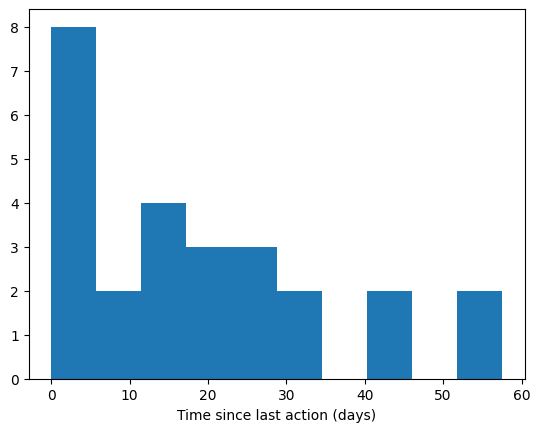

In [39]:
plt.hist(np.array(previous_time_diffs))
plt.xlabel('Time since last action (days)')
plt.show()

## Time Series Analysis

In [3]:
df = pd.read_parquet("data/train_data2_flattened.parquet")

In [25]:
len(np.where(df.loc[0, 'event_names'] == 'promotion_created')[0])

0

In [26]:
(df.loc[1, 'timestamps'][np.where(df.loc[1, 'event_names'] == 'promotion_created')[0][0]] - df.loc[1, 'timestamps'][0]) / np.timedelta64(1, 'D')

np.float64(36.959467592592596)

In [13]:
(df.loc[1, 'event_names'] == 'promotion_created').sum()

np.int64(7)

In [28]:
i = 0
while True:
    if 'order_shipped' in df.loc[i, 'event_names']:
        break
    i += 1

In [32]:
start_dates = []
num_promotions = []
days_to_first_promotion = []
is_successful = []

for row in df.itertuples(index=False):
    start_dates.append(row.timestamps[0].astype('datetime64[D]'))
    num_promotions.append((row.event_names == 'promotion_created').sum())
    promotion_event_indices = np.where(row.event_names == 'promotion_created')[0]
    if len(promotion_event_indices) > 0:
        days_to_first_promotion.append((row.timestamps[promotion_event_indices[0]] - row.timestamps[0]) / np.timedelta64(1, 'D'))
    else:
        days_to_first_promotion.append(np.nan)

    is_successful.append('order_shipped' in row.event_names)

In [33]:
journey_info = pd.DataFrame(
    {
        'start_date': start_dates,
        'num_promotions': num_promotions,
        'days_to_first_promotion': days_to_first_promotion,
        'successful': is_successful
    }
)

In [36]:
journey_info.head()

,start_date,num_promotions,days_to_first_promotion,successful
0,2022-10-31,0,NaN,False
1,2021-11-11,7,36.959468,False
2,2022-05-09,3,0.299086,False
3,2021-03-21,3,0.042731,False
4,2022-12-02,0,NaN,False


In [37]:
average_promos = journey_info.groupby('start_date')['num_promotions'].mean()

In [41]:
total_promos = journey_info.groupby('start_date')['num_promotions'].sum().resample('MS').sum()

In [46]:
total_journeys = journey_info.groupby('start_date')['num_promotions'].count().resample('MS').sum()

In [47]:
total_journeys.head()

start_date
2020-11-01     1361
2020-12-01     5276
2021-01-01    69904
2021-02-01    72723
2021-03-01    88677
Freq: MS, Name: num_promotions, dtype: int64

In [42]:
total_promos.head()

start_date
2020-11-01      7348
2020-12-01     29504
2021-01-01    365786
2021-02-01    400804
2021-03-01    560932
Freq: MS, Name: num_promotions, dtype: int64

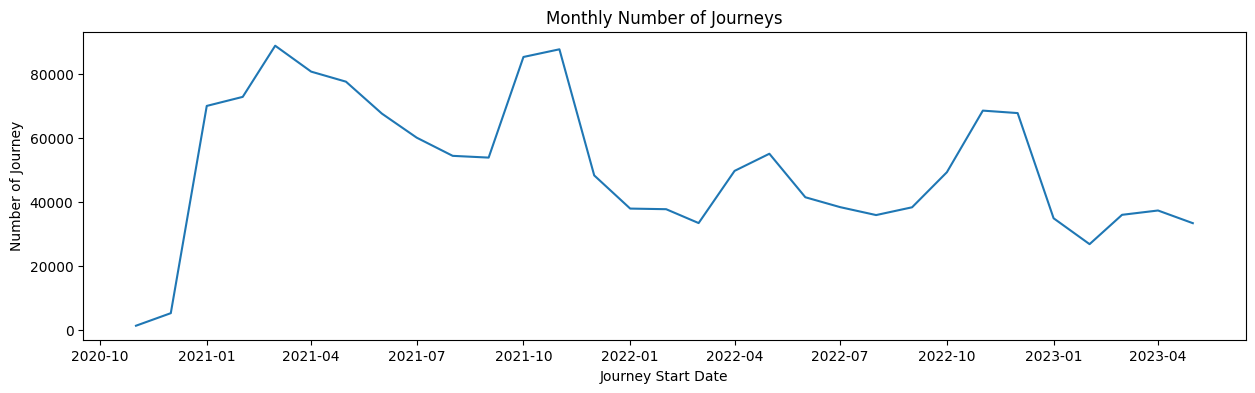

In [88]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Number of Journey')
plt.title('Monthly Number of Journeys')
plt.show()

In [89]:
successful_journeys = journey_info.groupby('start_date')['successful'].sum().resample('MS').sum()

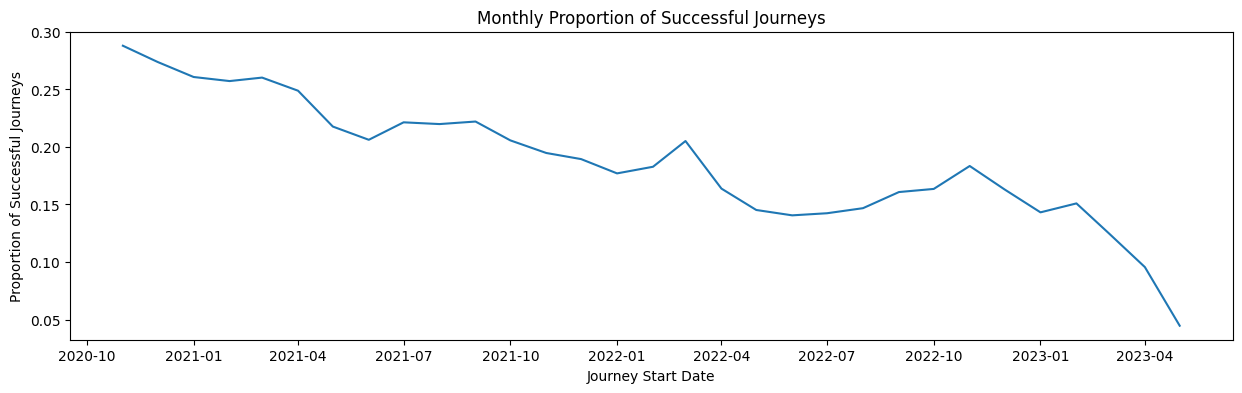

In [90]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, successful_journeys / total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Successful Journeys')
plt.title('Monthly Proportion of Successful Journeys')
plt.show()

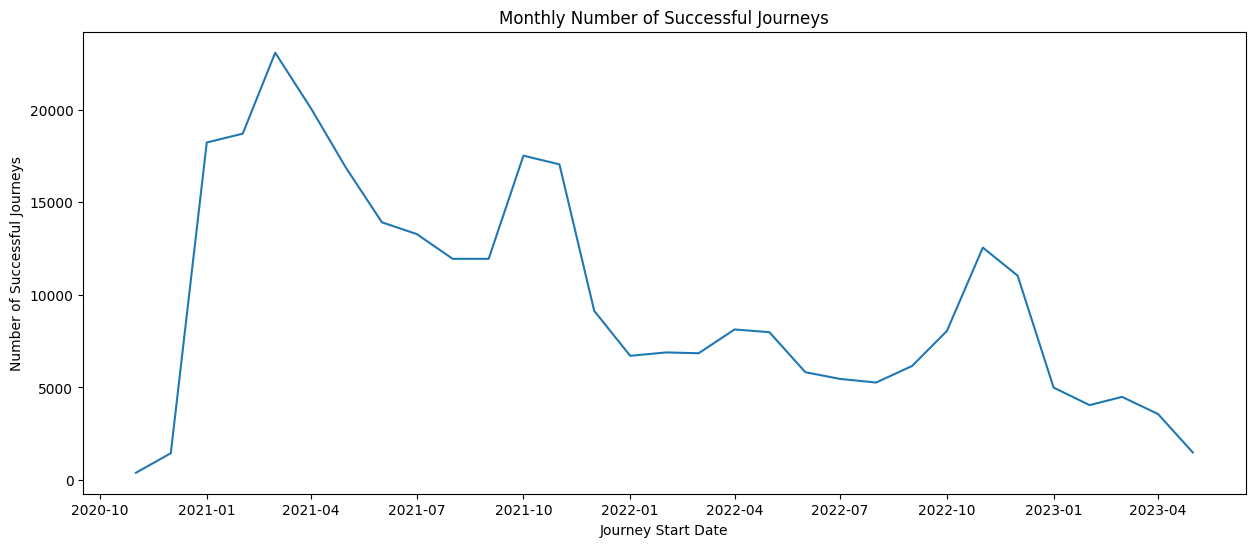

In [91]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, successful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Number of Successful Journeys')
plt.title('Monthly Number of Successful Journeys')
plt.show()

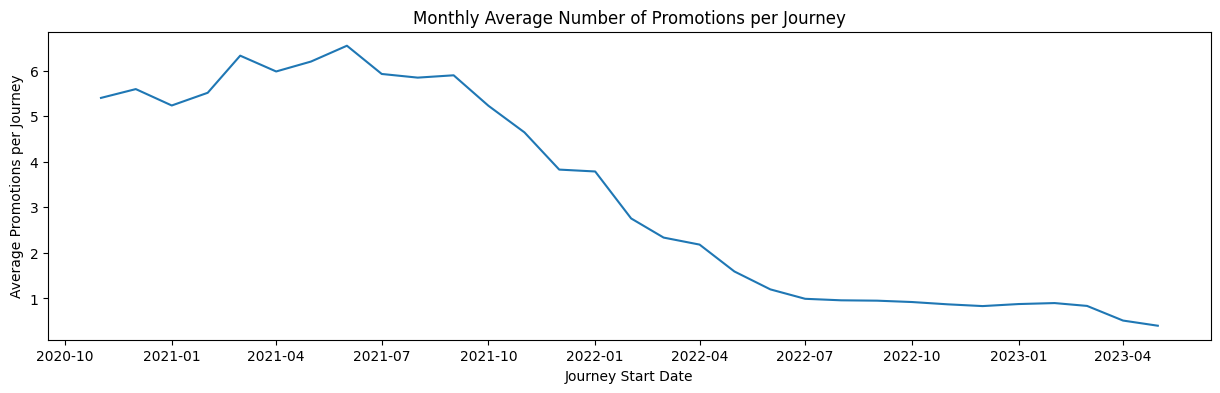

In [92]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, total_promos / total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Average Promotions per Journey')
plt.title('Monthly Average Number of Promotions per Journey')
plt.show()

In [93]:
no_promo_counts = journey_info.groupby('start_date')['days_to_first_promotion'].apply(lambda x: x.isna().sum()).resample('MS').sum()

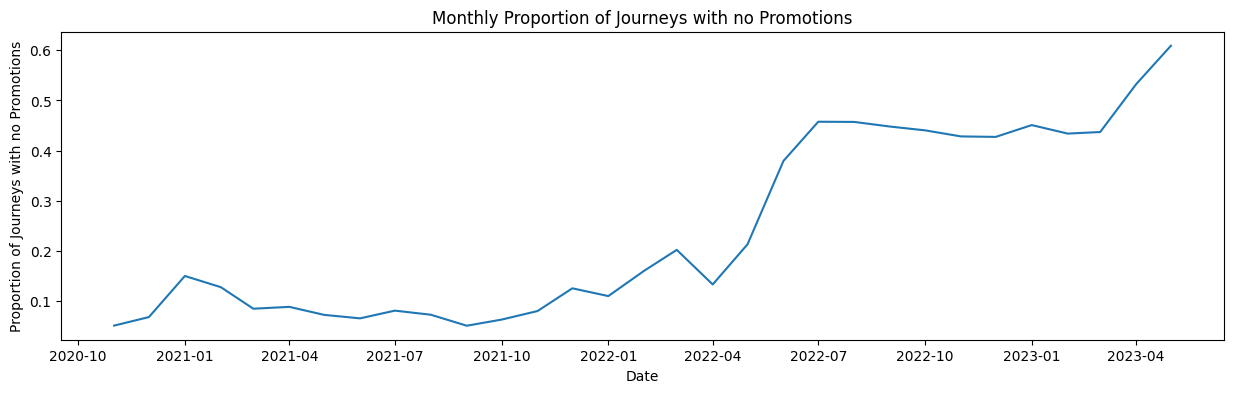

In [94]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, no_promo_counts / total_journeys)
plt.xlabel('Date')
plt.ylabel('Proportion of Journeys with no Promotions')
plt.title('Monthly Proportion of Journeys with no Promotions')
plt.show()

In [95]:
successful_journeys_no_promo = journey_info[journey_info['successful']].groupby('start_date')['days_to_first_promotion'].apply(lambda x: x.isna().sum()).resample('MS').sum()

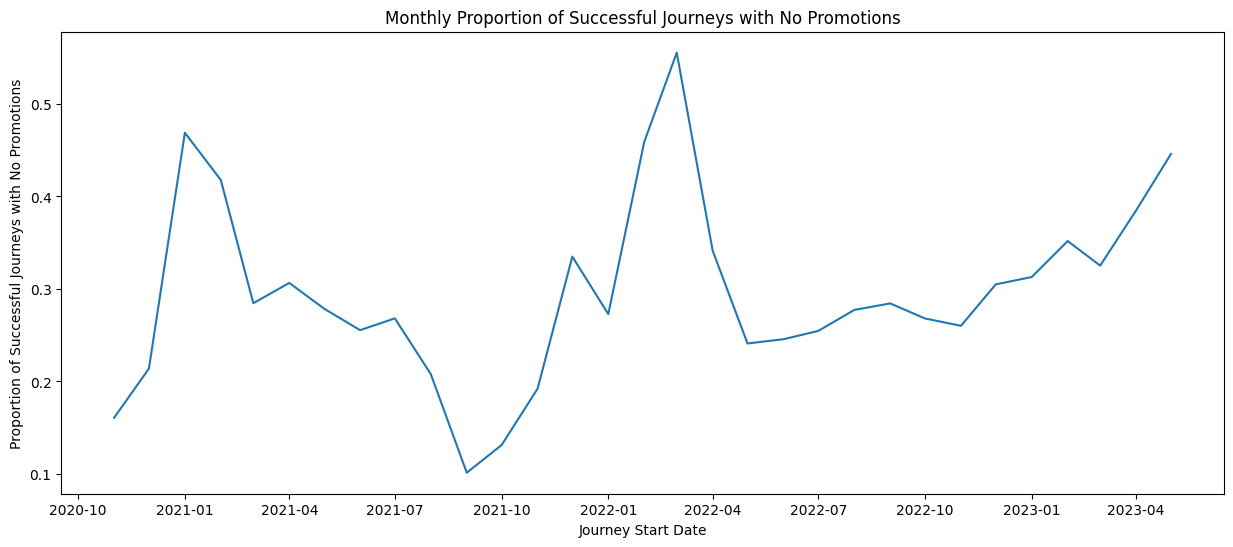

In [96]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, successful_journeys_no_promo / successful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Successful Journeys with No Promotions')
plt.title('Monthly Proportion of Successful Journeys with No Promotions')
plt.show()

In [97]:
total_promos_successful_journeys_exclude_none = journey_info[(journey_info['successful']) & ~(journey_info['days_to_first_promotion'].isna())].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

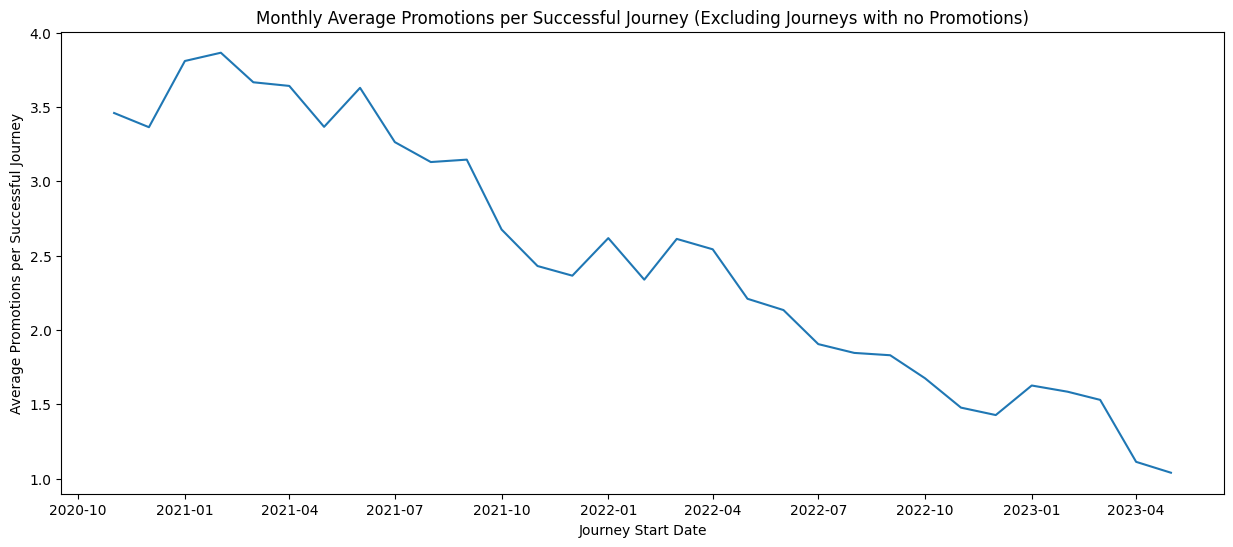

In [98]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, total_promos_successful_journeys_exclude_none / (successful_journeys - successful_journeys_no_promo))
plt.xlabel('Journey Start Date')
plt.ylabel('Average Promotions per Successful Journey')
plt.title('Monthly Average Promotions per Successful Journey (Excluding Journeys with no Promotions)')
plt.show()

In [99]:
total_promos_successful_journeys = journey_info[journey_info['successful']].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

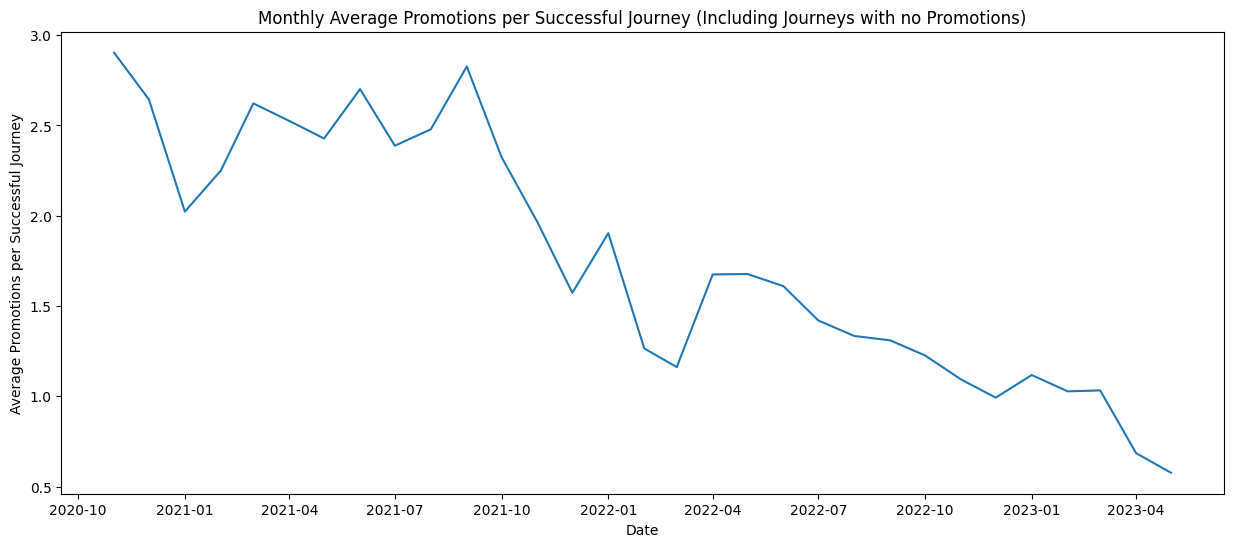

In [100]:
plt.figure(figsize=(15, 6))
plt.plot(successful_journeys.index, total_promos_successful_journeys / successful_journeys)
plt.xlabel('Date')
plt.ylabel('Average Promotions per Successful Journey')
plt.title('Monthly Average Promotions per Successful Journey (Including Journeys with no Promotions)')
plt.show()

REPEAT FOR UNSUCCESSFUL JOURNEYS, COMPARE WITH SUCCESSFUL

In [102]:
unsuccessful_journeys = journey_info[~journey_info['successful']].groupby('start_date')['successful'].count().resample('MS').sum()

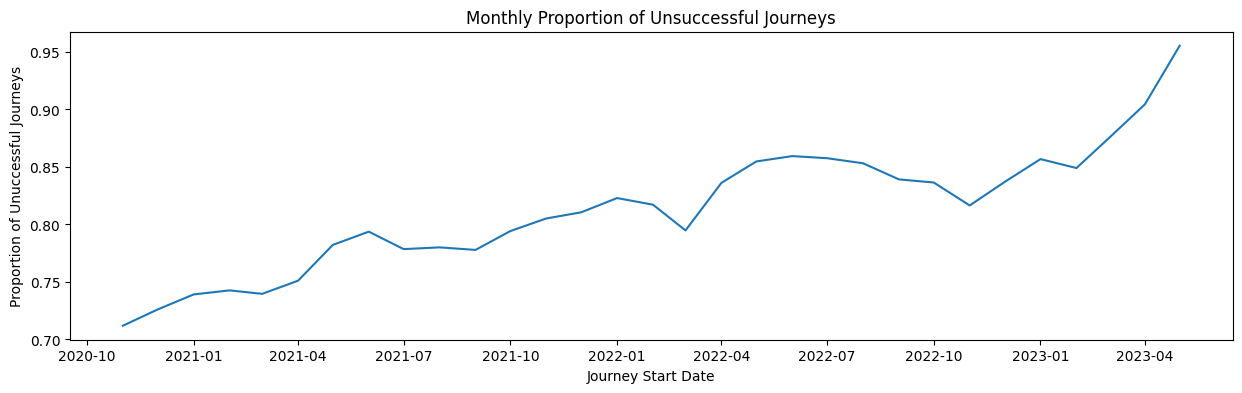

In [106]:
plt.figure(figsize=(15, 4))
plt.plot(total_journeys.index, unsuccessful_journeys / total_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Unuccessful Journeys')
plt.title('Monthly Proportion of Unsuccessful Journeys')
plt.show()

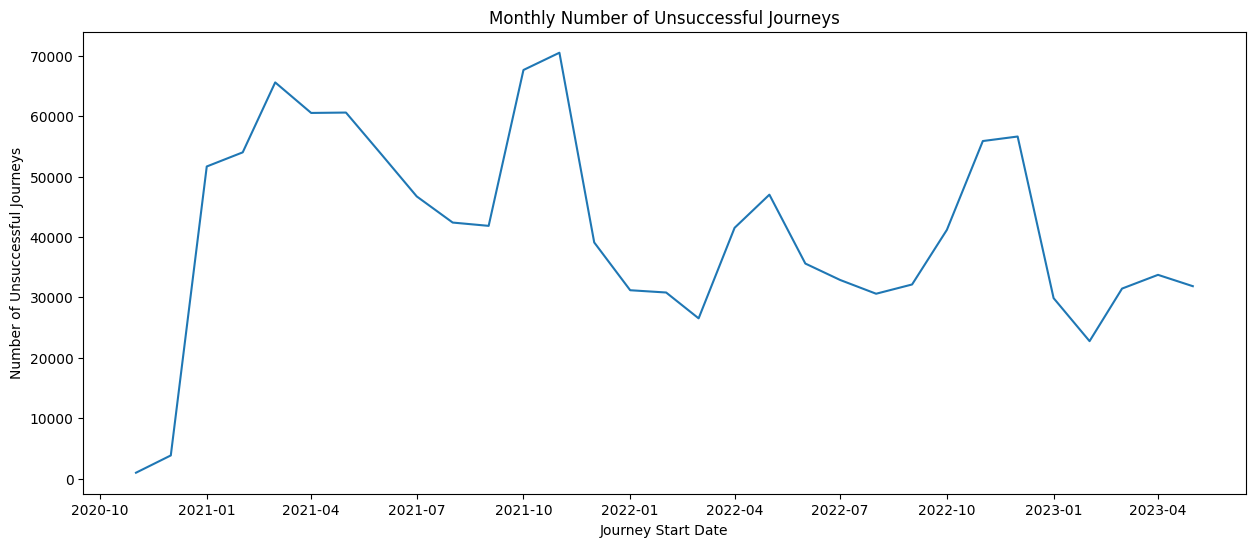

In [107]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, unsuccessful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Number of Unsuccessful Journeys')
plt.title('Monthly Number of Unsuccessful Journeys')
plt.show()

In [108]:
unsuccessful_journeys_no_promo = journey_info[~journey_info['successful']].groupby('start_date')['days_to_first_promotion'].apply(lambda x: x.isna().sum()).resample('MS').sum()

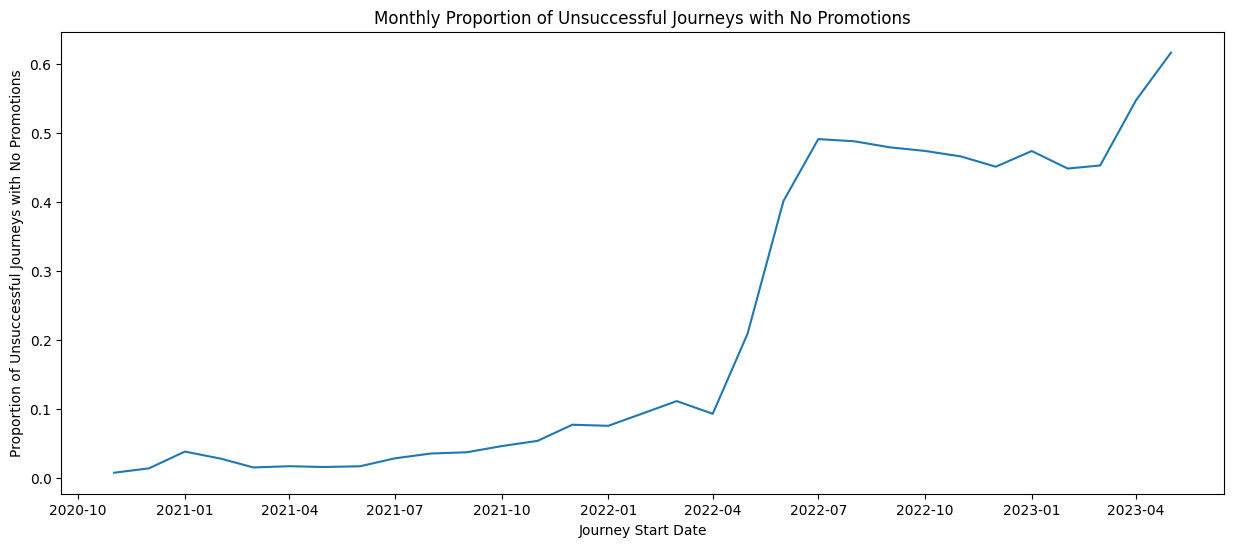

In [109]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, unsuccessful_journeys_no_promo / unsuccessful_journeys)
plt.xlabel('Journey Start Date')
plt.ylabel('Proportion of Unsuccessful Journeys with No Promotions')
plt.title('Monthly Proportion of Unsuccessful Journeys with No Promotions')
plt.show()

In [110]:
total_promos_unsuccessful_journeys_exclude_none = journey_info[(~journey_info['successful']) & ~(journey_info['days_to_first_promotion'].isna())].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

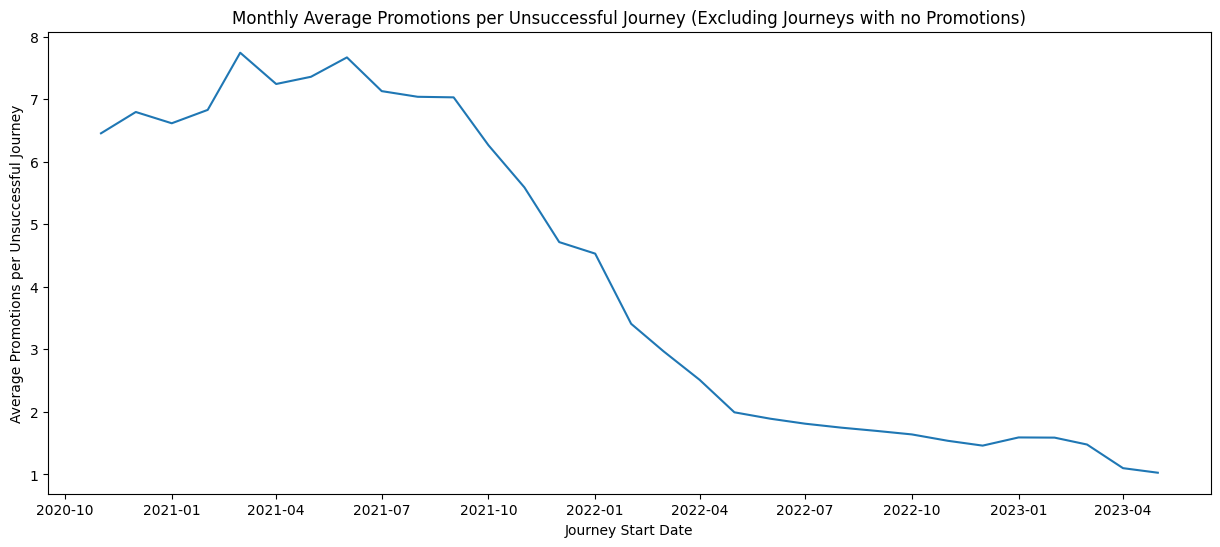

In [111]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, total_promos_unsuccessful_journeys_exclude_none / (unsuccessful_journeys - unsuccessful_journeys_no_promo))
plt.xlabel('Journey Start Date')
plt.ylabel('Average Promotions per Unsuccessful Journey')
plt.title('Monthly Average Promotions per Unsuccessful Journey (Excluding Journeys with no Promotions)')
plt.show()

In [113]:
total_promos_unsuccessful_journeys = journey_info[~journey_info['successful']].groupby('start_date')['num_promotions'].sum().resample('MS').sum()

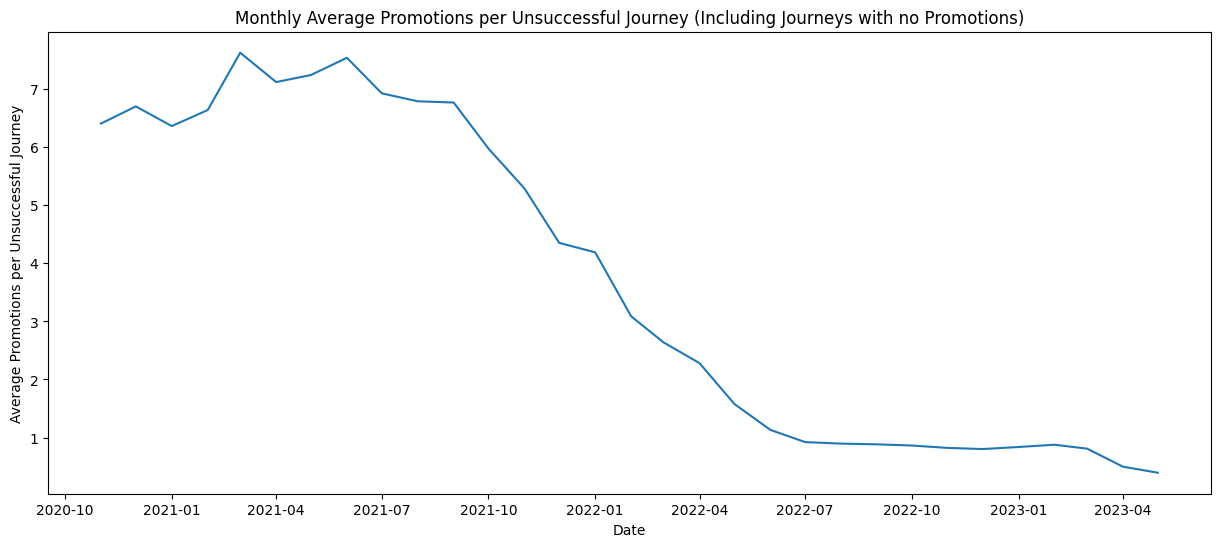

In [114]:
plt.figure(figsize=(15, 6))
plt.plot(unsuccessful_journeys.index, total_promos_unsuccessful_journeys / unsuccessful_journeys)
plt.xlabel('Date')
plt.ylabel('Average Promotions per Unsuccessful Journey')
plt.title('Monthly Average Promotions per Unsuccessful Journey (Including Journeys with no Promotions)')
plt.show()